# PigeonPilot — Reservoir A vs B

**Research question:** Does STDP in a recurrent LIF reservoir improve path integration
compared to a fixed (non-plastic) reservoir?

| Model | Reservoir | Readout |
|-------|-----------|---------|
| **A** | Fixed dense recurrent LIF | `RidgeClassifier` → home heading bin |
| **B** | Same init + STDP (`WeightDependentPostPre`) | same |

**Jury metric:** circular bin error × 10° (not X/Y MSE).

### Step 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from sklearn.linear_model import RidgeClassifier

from bindsnet.network import Network
from bindsnet.network.nodes import Input, LIFNodes
from bindsnet.network.topology import Connection
from bindsnet.network.monitors import Monitor
from bindsnet.learning import WeightDependentPostPre

from pigeonpilot.paths import (
    STYLES,
    DIFFICULTIES,
    DEFAULT_HEADING_BINS,
    FULL_CIRCLE_DEG,
    Segment,
    generate_level,
)
from pigeonpilot.encoding import (
    encode_level,
    compass_bin,
    heading_to_bin,
    plan_encoding,
)
from pigeonpilot.curriculum import (
    DEFAULT_EPOCHS_PER_DIFFICULTY,
    curriculum_level_count,
    format_curriculum_table,
    format_style_labels_table,
    generate_curriculum_dataset,
    split_dataset,
    summarize_dataset,
    iter_train_schedule,
)
from pigeonpilot.viz import (
    plot_level,
    plot_level_encoding,
    plot_body_ring_anatomy,
    plot_level_ring_frames,
    plot_levels_grid,
    plot_release_points,
    compute_xy_limits,
    plot_spike_raster,
)

print("imports ok")
print("torch", torch.__version__)
print("trajectory families:", STYLES)
display(Markdown("### Trajectory family labels (`STYLE_LABELS`)"))
display(Markdown(format_style_labels_table()))

imports ok
torch 2.11.0
trajectory families: ('linear', 'turning', 'curved')


### Trajectory family labels (`STYLE_LABELS`)

| Name | Meaning |
|------|---------|
| `linear` | straight / direct |
| `turning` | heading jumps (turns) |
| `curved` | wave or sweeping arc |

### Step 2: Create Dataset

In [2]:
DATASET_SEED = 42
SPLIT_SEED = 0
EXPECTED_N = curriculum_level_count()

dataset = generate_curriculum_dataset(seed=DATASET_SEED)
print(summarize_dataset(dataset))
assert len(dataset) == EXPECTED_N, f"expected {EXPECTED_N}, got {len(dataset)}"

train_set, test_set = split_dataset(dataset, train_frac=0.8, seed=SPLIT_SEED)
print(f"train: {len(train_set)} | test: {len(test_set)}")

xlim_global, ylim_global = compute_xy_limits(dataset)

# For visualization remove the comment
#
# for difficulty in DIFFICULTIES:
#     subset = [lv for lv in dataset if lv.difficulty == difficulty]
#     plot_levels_grid(subset, title=f"Difficulty: {difficulty}")
#     plt.show()

{'total': 150, 'by_difficulty': {'easy': 60, 'medium': 60, 'hard': 30}, 'by_style': {'linear': 30, 'turning': 75, 'curved': 45}}
train: 120 | test: 30


### Step 3: Hyperparameters, helpers (labels + metric + tensor adapter)

Encoding uses a fine `dt` plus trailing silence so the LIF reservoir has time to integrate.
Home direction labels are **derived** from `home_xy` (not stored on `Level`).

In [3]:
# --- hyperparameters ---
N_INPUT = DEFAULT_HEADING_BINS  # 36
N_RES = 150
NET_DT = 1.0
ENCODING_DT = 0.05  # longer spike trains than dt=1
ENCODING_VELOCITY = 1.0
TRAILING_SILENCE = 20  # washout / integration tail

WEIGHT_SEED = 0
FF_SCALE = 0.8  # strong enough for LIF to fire within short paths
REC_SCALE = 0.02  # keep dense recurrence subthreshold-ish
WMIN, WMAX = 0.0, 1.0  # STDP bounds; pair with small STDP_NU


LIF_KW = dict(rest=-65.0, reset=-65.0, thresh=-52.0, refrac=5)
STDP_NU = (1e-5, 1e-4)  # conservative: dense recurrence + STDP risks runaway
STDP_TC = 20.0

# Plasticity schedule (shorter than DEFAULT for hackathon runtime; raise for full runs)
STDP_EPOCHS_PER_DIFFICULTY = {"easy": 8, "medium": 5, "hard": 3}

RIDGE_ALPHA = 1.0


def home_heading_deg(home_xy) -> float:
    """Compass degrees of the home vector (0°=N/+y, 90°=E/+x)."""
    x, y = float(home_xy[0]), float(home_xy[1])
    return float(np.degrees(np.arctan2(x, y)) % FULL_CIRCLE_DEG)


def home_bin(level, heading_bins: int = DEFAULT_HEADING_BINS) -> int:
    """Classification label: heading bin of home_xy."""
    return compass_bin(home_heading_deg(level.home_xy), heading_bins)


def circular_bin_error(
    true_bin: int,
    pred_bin: int,
    heading_bins: int = DEFAULT_HEADING_BINS,
) -> tuple[int, float]:
    """Return (bin_error, degrees)."""
    d = abs(int(true_bin) - int(pred_bin)) % heading_bins
    d = min(d, heading_bins - d)
    return d, d * (FULL_CIRCLE_DEG / heading_bins)


def encode_level_for_net(level) -> np.ndarray:
    """Rate-code spikes + trailing silence → (T, 36) float32."""
    spikes = encode_level(
        level, velocity=ENCODING_VELOCITY, dt=ENCODING_DT, heading_bins=N_INPUT
    )
    if TRAILING_SILENCE > 0:
        pad = np.zeros((TRAILING_SILENCE, N_INPUT), dtype=np.float32)
        spikes = np.vstack([spikes, pad])
    return spikes


def to_bindsnet_input(spikes: np.ndarray) -> torch.Tensor:
    """(T, n) → [T, batch=1, n] float tensor."""
    return torch.from_numpy(np.asarray(spikes, dtype=np.float32)).unsqueeze(1)


def pool_reservoir_state(spike_tensor: torch.Tensor) -> np.ndarray:
    """Mean spike rate over time → (N_RES,) feature vector."""
    # spike_tensor: [time, batch, n]
    return spike_tensor.float().mean(dim=0).squeeze(0).detach().cpu().numpy()


# Sanity: South home ≈ bin 18; pred bin 19 → 1 bin = 10°
_south = type("L", (), {"home_xy": (0.0, -1.0)})()
assert home_bin(_south) == 18, home_bin(_south)
bins_err, deg_err = circular_bin_error(18, 19)
assert bins_err == 1 and deg_err == 10.0, (bins_err, deg_err)
print("helpers ok | ENCODING_DT=", ENCODING_DT, "| TRAILING_SILENCE=", TRAILING_SILENCE)
print("example train home_bin:", home_bin(train_set[0]), "heading°:", round(home_heading_deg(train_set[0].home_xy), 1))

helpers ok | ENCODING_DT= 0.05 | TRAILING_SILENCE= 20
example train home_bin: 12 heading°: 120.0


### Step 4: Build identical reservoirs A (fixed) and B (STDP)

Dense recurrent all-to-all (diagonal zero). Same random init for A and B.

In [4]:
def init_weights(n_input: int, n_res: int, seed: int = WEIGHT_SEED):
    g = torch.Generator().manual_seed(seed)
    w_ff = FF_SCALE * torch.rand(n_input, n_res, generator=g)
    w_rec = REC_SCALE * torch.rand(n_res, n_res, generator=g)
    w_rec.fill_diagonal_(0.0)
    return w_ff, w_rec


def build_reservoir(
    *,
    plastic: bool,
    w_ff: torch.Tensor,
    w_rec: torch.Tensor,
    dt: float = NET_DT,
) -> Network:
    """Input(36) → dense recurrent LIF reservoir. plastic=True → STDP on FF + Rec."""
    n_input, n_res = w_ff.shape
    assert w_rec.shape == (n_res, n_res)

    net = Network(dt=dt)
    input_layer = Input(n=n_input, traces=True)
    reservoir = LIFNodes(n=n_res, traces=True, **LIF_KW)
    net.add_layer(input_layer, name="Input")
    net.add_layer(reservoir, name="Reservoir")

    conn_kwargs = dict(wmin=WMIN, wmax=WMAX)
    if plastic:
        conn_kwargs.update(
            update_rule=WeightDependentPostPre,
            nu=STDP_NU,
            tc_pre=STDP_TC,
            tc_post=STDP_TC,
        )

    ff = Connection(
        source=input_layer,
        target=reservoir,
        w=w_ff.clone(),
        **conn_kwargs,
    )
    rec = Connection(
        source=reservoir,
        target=reservoir,
        w=w_rec.clone(),
        **conn_kwargs,
    )
    net.add_connection(ff, source="Input", target="Reservoir")
    net.add_connection(rec, source="Reservoir", target="Reservoir")

    net.add_monitor(
        Monitor(obj=reservoir, state_vars=["s"], time=None),
        name="Res spikes",
    )
    return net


w_ff0, w_rec0 = init_weights(N_INPUT, N_RES, seed=WEIGHT_SEED)
net_a = build_reservoir(plastic=False, w_ff=w_ff0, w_rec=w_rec0)
net_b = build_reservoir(plastic=True, w_ff=w_ff0, w_rec=w_rec0)

# identical start weights
assert torch.allclose(
    net_a.connections[("Input", "Reservoir")].w,
    net_b.connections[("Input", "Reservoir")].w,
)
assert torch.allclose(
    net_a.connections[("Reservoir", "Reservoir")].w,
    net_b.connections[("Reservoir", "Reservoir")].w,
)
assert torch.count_nonzero(
    torch.diag(net_a.connections[("Reservoir", "Reservoir")].w)
) == 0

print(net_a)
print("A plastic rules:", {k: c.update_rule for k, c in net_a.connections.items()})
print("B plastic rules:", {k: type(c.update_rule).__name__ if c.update_rule else None for k, c in net_b.connections.items()})
print("w_ff mean", float(w_ff0.mean()), "| w_rec mean (off-diag)", float(w_rec0[~torch.eye(N_RES, dtype=bool)].mean()))

Network(
  (Input): Input()
  (Reservoir): LIFNodes()
  (Input_to_Reservoir): Connection(
    (source): Input()
    (target): LIFNodes()
  )
  (Reservoir_to_Reservoir): Connection(
    (source): LIFNodes()
    (target): LIFNodes()
  )
)
A plastic rules: {('Input', 'Reservoir'): <bindsnet.learning.learning.NoOp object at 0x10867f110>, ('Reservoir', 'Reservoir'): <bindsnet.learning.learning.NoOp object at 0x134cab610>}
B plastic rules: {('Input', 'Reservoir'): 'WeightDependentPostPre', ('Reservoir', 'Reservoir'): 'WeightDependentPostPre'}
w_ff mean 0.39653143286705017 | w_rec mean (off-diag) 0.010087176226079464


### Step 5: Smoke-test one easy level

smoke level_id=0 T=53 home_bin=12 res_spikes=74 active=74/150


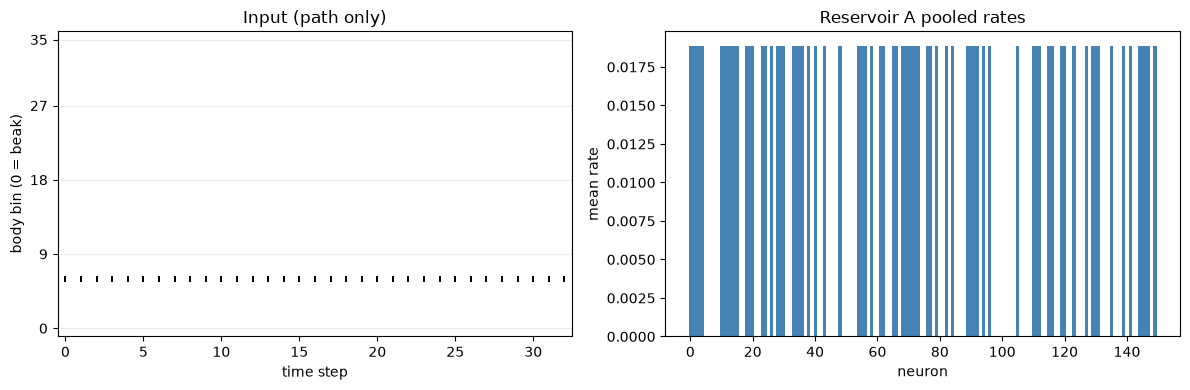

smoke ok


In [5]:
smoke_level = next(lv for lv in train_set if lv.difficulty == "easy")
smoke_spikes = encode_level_for_net(smoke_level)
smoke_input = to_bindsnet_input(smoke_spikes)
T_smoke = smoke_spikes.shape[0]

net_a.train(False)
net_a.run(inputs={"Input": smoke_input}, time=T_smoke)
s_a = net_a.monitors["Res spikes"].get("s")
state_a = pool_reservoir_state(s_a)
print(
    f"smoke level_id={smoke_level.level_id} T={T_smoke} "
    f"home_bin={home_bin(smoke_level)} "
    f"res_spikes={float(s_a.sum()):.0f} "
    f"active={(state_a > 0).sum()}/{N_RES}"
)
assert s_a.sum() > 0, "Reservoir A produced no spikes — raise FF_SCALE or ENCODING length"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_spike_raster(smoke_spikes[: max(1, T_smoke - TRAILING_SILENCE)], ax=axes[0], title="Input (path only)")
axes[1].bar(np.arange(N_RES), state_a, width=1.0, color="steelblue")
axes[1].set_title("Reservoir A pooled rates")
axes[1].set_xlabel("neuron")
axes[1].set_ylabel("mean rate")
plt.tight_layout()
plt.show()

net_a.reset_state_variables()
print("smoke ok")

### Step 6: Model B plasticity phase (curriculum), then freeze

STDP runs unsupervised on train paths (`train(True)`). Afterwards weights are frozen for readout.

In [6]:
def run_trial(net: Network, level, learning: bool) -> np.ndarray:
    """Encode → run → pool state → reset. Returns pooled reservoir rates."""
    spikes = encode_level_for_net(level)
    inputs = to_bindsnet_input(spikes)
    net.train(learning)
    net.run(inputs={"Input": inputs}, time=spikes.shape[0])
    state = pool_reservoir_state(net.monitors["Res spikes"].get("s"))
    net.reset_state_variables()
    return state


w_ff_before = net_b.connections[("Input", "Reservoir")].w.detach().clone()
w_rec_before = net_b.connections[("Reservoir", "Reservoir")].w.detach().clone()

n_plastic_trials = 0
print("STDP curriculum:", STDP_EPOCHS_PER_DIFFICULTY)
for phase, phase_epoch, train_index, level in iter_train_schedule(
    train_set,
    mode="curriculum",
    epochs_per_difficulty=STDP_EPOCHS_PER_DIFFICULTY,
    seed=0,
):
    run_trial(net_b, level, learning=True)
    n_plastic_trials += 1
    if n_plastic_trials % 100 == 0:
        print(f"  ... {n_plastic_trials} plastic trials (phase={phase}, epoch={phase_epoch})")

net_b.train(False)

w_ff_after = net_b.connections[("Input", "Reservoir")].w.detach()
w_rec_after = net_b.connections[("Reservoir", "Reservoir")].w.detach()
ff_delta = float((w_ff_after - w_ff_before).abs().mean())
rec_delta = float((w_rec_after - w_rec_before).abs().mean())
print(f"plastic trials: {n_plastic_trials}")
print(f"mean |Δw| FF={ff_delta:.6f}  Rec={rec_delta:.6f}")
assert ff_delta > 0 or rec_delta > 0, "STDP did not change weights"
print("Model B frozen for readout")

STDP curriculum: {'easy': 8, 'medium': 5, 'hard': 3}


  ... 100 plastic trials (phase=easy, epoch=2)


  ... 200 plastic trials (phase=easy, epoch=4)


  ... 300 plastic trials (phase=easy, epoch=6)


  ... 400 plastic trials (phase=medium, epoch=0)


  ... 500 plastic trials (phase=medium, epoch=2)


  ... 600 plastic trials (phase=medium, epoch=4)


plastic trials: 696
mean |Δw| FF=0.001402  Rec=0.036191
Model B frozen for readout


### Step 7: Collect states + fit RidgeClassifier (A and B)

Target = `home_bin(level)` ∈ {0…35}.

In [7]:
def collect_states(net: Network, levels) -> tuple[np.ndarray, np.ndarray, list]:
    """Return X (n, N_RES), y home bins, and difficulty list."""
    X, y, diffs = [], [], []
    for i, level in enumerate(levels):
        state = run_trial(net, level, learning=False)
        X.append(state)
        y.append(home_bin(level))
        diffs.append(level.difficulty)
        if (i + 1) % 40 == 0:
            print(f"  collected {i + 1}/{len(levels)}")
    return np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.int64), diffs


print("Collecting train states — Model A")
X_train_a, y_train_a, _ = collect_states(net_a, train_set)
print("Collecting train states — Model B")
X_train_b, y_train_b, _ = collect_states(net_b, train_set)

print("Collecting test states — Model A")
X_test_a, y_test_a, test_diffs = collect_states(net_a, test_set)
print("Collecting test states — Model B")
X_test_b, y_test_b, _ = collect_states(net_b, test_set)

assert np.array_equal(y_train_a, y_train_b)
assert np.array_equal(y_test_a, y_test_b)
print("unique train bins:", len(np.unique(y_train_a)), "/ 36")

clf_a = RidgeClassifier(alpha=RIDGE_ALPHA)
clf_b = RidgeClassifier(alpha=RIDGE_ALPHA)
clf_a.fit(X_train_a, y_train_a)
clf_b.fit(X_train_b, y_train_b)
print("RidgeClassifiers fitted")

  collected 40/120


  collected 80/120


  collected 120/120


  collected 40/120


  collected 80/120


  collected 120/120


unique train bins: 34 / 36
RidgeClassifiers fitted


### Step 8: Evaluation — circular angular error

In [8]:
def angular_errors(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    bins_err = np.empty(len(y_true), dtype=np.int64)
    deg_err = np.empty(len(y_true), dtype=np.float64)
    for i, (t, p) in enumerate(zip(y_true, y_pred)):
        b, d = circular_bin_error(int(t), int(p))
        bins_err[i] = b
        deg_err[i] = d
    return bins_err, deg_err


pred_a = clf_a.predict(X_test_a)
pred_b = clf_b.predict(X_test_b)
bins_a, deg_a = angular_errors(y_test_a, pred_a)
bins_b, deg_b = angular_errors(y_test_b, pred_b)

acc_a = float((pred_a == y_test_a).mean())
acc_b = float((pred_b == y_test_b).mean())

summary = {
    "A": {"mean_deg": float(deg_a.mean()), "std_deg": float(deg_a.std()), "exact_acc": acc_a},
    "B": {"mean_deg": float(deg_b.mean()), "std_deg": float(deg_b.std()), "exact_acc": acc_b},
}

print("=== Test angular error (circular) ===")
print(
    f"Taube A (fixed):  mean {summary['A']['mean_deg']:.1f}° ± {summary['A']['std_deg']:.1f}°  "
    f"| exact-bin acc {100 * acc_a:.1f}%"
)
print(
    f"Taube B (STDP):   mean {summary['B']['mean_deg']:.1f}° ± {summary['B']['std_deg']:.1f}°  "
    f"| exact-bin acc {100 * acc_b:.1f}%"
)

print("\nBy difficulty (mean °):")
for diff in DIFFICULTIES:
    mask = np.array([d == diff for d in test_diffs])
    if not mask.any():
        continue
    print(
        f"  {diff:8s}  A={deg_a[mask].mean():5.1f}°   B={deg_b[mask].mean():5.1f}°   n={mask.sum()}"
    )

=== Test angular error (circular) ===
Taube A (fixed):  mean 68.7° ± 47.3°  | exact-bin acc 3.3%
Taube B (STDP):   mean 74.7° ± 46.7°  | exact-bin acc 3.3%

By difficulty (mean °):
  easy      A= 45.8°   B= 57.5°   n=12
  medium    A= 66.7°   B= 70.0°   n=12
  hard      A=118.3°   B=118.3°   n=6


### Step 9: Jury comparison plots

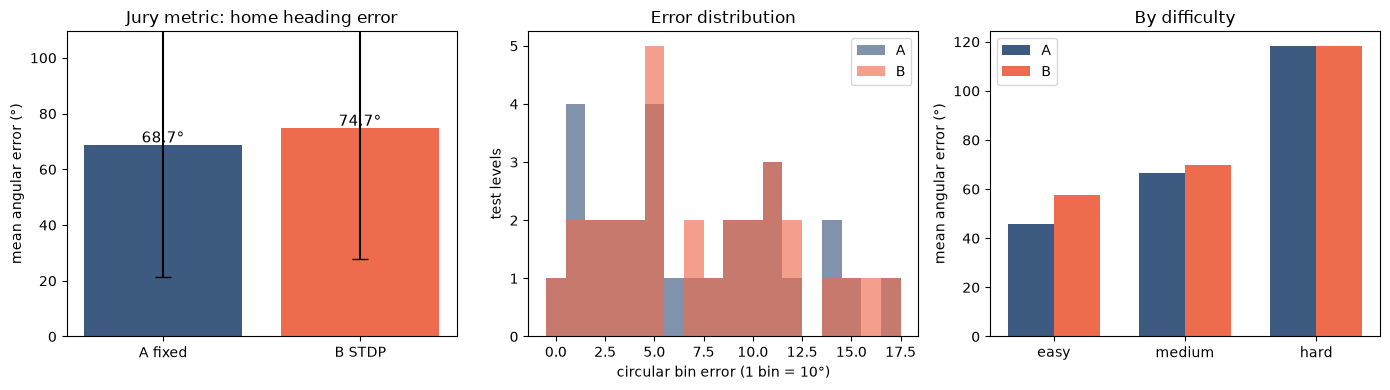

Headline: Taube A 69° vs Taube B 75° → better: A (fixed)
Interpretation: STDP may overwrite the reservoir's fading short-term memory.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Mean angular error bar
ax = axes[0]
means = [summary["A"]["mean_deg"], summary["B"]["mean_deg"]]
stds = [summary["A"]["std_deg"], summary["B"]["std_deg"]]
bars = ax.bar(["A fixed", "B STDP"], means, yerr=stds, color=["#3d5a80", "#ee6c4d"], capsize=6)
ax.set_ylabel("mean angular error (°)")
ax.set_title("Jury metric: home heading error")
ax.set_ylim(0, max(means) * 1.4 + 5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 1, f"{m:.1f}°", ha="center", fontsize=11)

# 2) Histogram of bin errors
ax = axes[1]
max_bin = max(int(bins_a.max()), int(bins_b.max()), 1)
bins_edges = np.arange(0, max_bin + 2) - 0.5
ax.hist(bins_a, bins=bins_edges, alpha=0.65, label="A", color="#3d5a80")
ax.hist(bins_b, bins=bins_edges, alpha=0.65, label="B", color="#ee6c4d")
ax.set_xlabel("circular bin error (1 bin = 10°)")
ax.set_ylabel("test levels")
ax.set_title("Error distribution")
ax.legend()

# 3) Per-difficulty means
ax = axes[2]
x = np.arange(len(DIFFICULTIES))
width = 0.35
means_a_d, means_b_d = [], []
for diff in DIFFICULTIES:
    mask = np.array([d == diff for d in test_diffs])
    means_a_d.append(float(deg_a[mask].mean()) if mask.any() else 0.0)
    means_b_d.append(float(deg_b[mask].mean()) if mask.any() else 0.0)
ax.bar(x - width / 2, means_a_d, width, label="A", color="#3d5a80")
ax.bar(x + width / 2, means_b_d, width, label="B", color="#ee6c4d")
ax.set_xticks(x)
ax.set_xticklabels(DIFFICULTIES)
ax.set_ylabel("mean angular error (°)")
ax.set_title("By difficulty")
ax.legend()

plt.tight_layout()
plt.show()

winner = "A (fixed)" if summary["A"]["mean_deg"] <= summary["B"]["mean_deg"] else "B (STDP)"
print(
    f"Headline: Taube A {summary['A']['mean_deg']:.0f}° vs Taube B {summary['B']['mean_deg']:.0f}° "
    f"→ better: {winner}"
)
if summary["A"]["mean_deg"] < summary["B"]["mean_deg"]:
    print("Interpretation: STDP may overwrite the reservoir's fading short-term memory.")
else:
    print("Interpretation: STDP appears to help (or not hurt) path-integration readout.")